<a href="https://colab.research.google.com/github/imranasalisu1/Hendeb_project/blob/main/Model4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

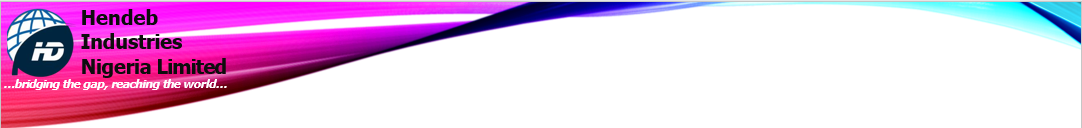
**MOLECULAR DESCRIPTORS & FEATURE ENGINEERING**

This module explains how chemical structures are transformed into numerical
descriptors for modeling. It introduces different categories of descriptors including
structural, topological, and 3D descriptors. Feature engineering techniques are
discussed to improve model performance. Participants learn how to reduce
redundancy in datasets. The importance of selecting relevant features is emphasized.

**1. Molecular Descriptors: The "DNA" of Chemical Data**

Molecular descriptors are mathematical representations of chemical properties. They transform a 3D or 2D chemical structure into a numerical format that a Machine Learning model can understand.


---

### **1. 1D (Compositional) Descriptors**
1D descriptors represent the simplest numerical summary of a molecule based strictly on its chemical formula. They do not account for how atoms are connected or their spatial arrangement; instead, they focus on the "inventory" of the molecule. Common examples include **Molecular Weight (MW)** and **Atom Counts** (e.g., the number of Carbon or Nitrogen atoms).
* **Analogy:** Think of this as a **Grocery Receipt**. It tells you exactly how many items you bought and the total weight of your bag, but it provides no information on whether those ingredients will be used to bake a cake or cook a stew.

### **2. 2D (Topological) Descriptors**
2D descriptors describe the "map" or connectivity of a molecule. They are calculated based on the arrangement of atoms and bonds (the molecular graph) without considering its 3D shape. Key examples include **LogP** (hydrophobicity), **Molar Refractivity**, and various **Topological Indices** (like the Wiener Index).
* **Analogy:** This is like a **Subway Map**. It shows you exactly which stations (atoms) are connected by which lines (bonds), allowing you to understand the "flow" of the system, even though the map doesn't show the actual curves or physical terrain of the city.

### **3. 3D (Geometrical) Descriptors**
3D descriptors capture the physical space a molecule occupies and its shape-dependent properties. Because molecules are flexible and can twist into different "conformations," these descriptors are more complex to calculate but highly accurate for understanding how a drug fits into a protein. Examples include **Molecular Volume**, **Polar Surface Area (3D)**, and **Shadow Indices**.
* **Analogy:** Think of this as a **Tailor’s Measurement**. While a subway map tells you how a person is "put together," 3D descriptors are the exact measurements of their chest, waist, and arms to ensure a suit (or a drug pocket) fits perfectly without being too tight or too loose.

### **4. Physicochemical Descriptors**
These descriptors define the intrinsic physical and chemical "personality" of the molecule. They dictate how a compound will behave in different environments, such as whether it will dissolve in water or get stuck in the fat of a cell membrane. Examples include **Boiling Point**, **pKa** (acidity), **TPSA** (Polar Surface Area), and the **Number of Rotatable Bonds**.
* **Analogy:** This is the **Gear Profile of a Hiker**. Does the hiker have waterproof boots? Is their pack too heavy to carry uphill? These traits determine if the hiker can survive the journey through the "wilderness" of the human body to reach their destination.

### **5. Bioactivity Descriptors**
Bioactivity descriptors quantify the effectiveness of a molecule in triggering a biological response. They are often the most important metrics in drug discovery because they tell you if a compound actually "works." Common examples include **$IC_{50}$** (inhibitory concentration), **MM-GBSA** (binding energy), and **$pEC_{50}$**.
* **Analogy:** This is the **Precision of a Key**. A key might have the right weight (1D) and the right metal (Physicochemical), but bioactivity measures how perfectly the "teeth" of the key align with the tumblers of a lock to actually turn it and open the door.

### **6. Toxicity Descriptors**
Toxicity descriptors identify the potential harmful effects a molecule might have on a living system. In computational research, these are often used as "red flags" to filter out dangerous compounds early. Examples include **hERG inhibition** (heart risk), **LD50** (lethal dose), **Ames Mutagenicity**, and **DILI** (liver injury) indicators.
* **Analogy:** Think of this as a **Safety Fire Rating**. Just because a building material is strong and cheap doesn't mean it's safe; if it releases toxic smoke during a fire, it is a "toxic" choice that must be avoided despite its other benefits.

### **7. Fingerprints (Morgan)**
Morgan Fingerprints (also known as ECFP) are circular descriptors that look at each atom and record the "neighborhood" around it up to a certain distance. This creates a unique digital signature for the molecule. Examples include **ECFP4** and **ECFP6**, which are industry standards in drug discovery.
* **Analogy:** This is like a **Neighborhood Snapshot**. Instead of describing a whole city, you describe what is immediately visible from your front porch: "I see a park, two red houses, and a blue car." If two snapshots match, the neighborhoods are likely very similar.

### **8. Vector Descriptors**
Vector descriptors translate a molecule into a fixed-length string of numbers (a coordinate) in a high-dimensional mathematical space. This allows AI models to perform complex math on chemical structures. Examples include **One-hot encoding of SMILES** and **Word2Vec (Mol2Vec)** embeddings.
* **Analogy:** This is like **GPS Coordinates**. Rather than saying "the big house on the corner," you provide the exact latitude and longitude. It’s a series of numbers that doesn't look like a "house" to humans but tells a computer exactly where that object is located in space.

### **9. PaDEL Descriptors**
PaDEL is a comprehensive software-based framework that generates a massive "package" of 1,875 different descriptors at once. It covers everything from atom counts to complex electronic states. Examples include **Constitutional**, **Electronic**, and **Fragment** counts.
* **Analogy:** Think of this as a **Full Medical Physical**. Instead of just checking your height or weight, the doctor runs a blood test, an X-ray, an MRI, and a vision test all at once to get a complete, massive data file on your health.

### **10. Lipinski (Rule of 5)**
The Lipinski descriptors are a specific set of four criteria used to predict if a molecule is "drug-like" enough to be absorbed by the human body when swallowed as a pill. The rules look at **MW < 500**, **LogP < 5**, **H-bond donors < 5**, and **H-bond acceptors < 10**.
* **Analogy:** This is the **"You Must Be This Tall to Ride"** sign at a theme park. It is a quick, simple sanity check to ensure the molecule isn't too big, too greasy, or too "sticky" to successfully ride the bloodstream.

### **11. PubChem Descriptors**
PubChem descriptors are a standardized "binary" checklist of 881 specific chemical features. For every molecule, the computer checks "Yes (1)" or "No (0)" for each feature on the list. Examples include the presence of **specific rings**, **halogens**, or **functional groups**.
* **Analogy:** This is like a **Customs Declaration Form**. You are given a list of 881 items (Alcohol? Plants? More than $10,000 cash?) and you simply check the boxes for everything you are currently carrying in your "molecular suitcase."

**2. Generating Descriptors**

In [3]:
# Install rdkit and numpy and pandas
! pip install rdkit pandas numpy
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Lipinski
import pandas as pd

def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None

    # 1D/Physicochemical/Lipinski
    results = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'H_Donors': Lipinski.NumHDonors(mol),
        'H_Acceptors': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol)
    }

    # 2D/Morgan Fingerprint (Vector)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
    results['Morgan_FP'] = list(fp)

    return results

# Example: Aspirin
smiles_list = ['CC(=O)OC1=CC=CC=C1C(=O)O']
data = [get_descriptors(s) for s in smiles_list]
df_desc = pd.DataFrame(data)
print(df_desc)

        MW    LogP  H_Donors  H_Acceptors  TPSA  \
0  180.159  1.3101         1            3  63.6   

                                           Morgan_FP  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...  


[22:05:55] DEPRECATION WARNING: please use MorganGenerator


**Calculating Representative Descriptors
This script demonstrates how to extract one example from each category using RDKit.**

In [4]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

def extract_descriptor_types(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None

    # 1. Physicochemical (Intrinsic property)
    physchem = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol)
    }

    # 2. Bioactivity/Drug-likeness (Likelihood of being active)
    # While true bioactivity comes from assays, we use Lipinski as a proxy
    bio_proxy = {
        'H_Bond_Donors': Lipinski.NumHDonors(mol),
        'Rotatable_Bonds': Lipinski.NumRotatableBonds(mol)
    }

    # 3. Toxicity (Structural Alerts)
    # Checking for specific toxic fragments (e.g., Nitro groups often linked to toxicity)
    has_nitro = mol.HasSubstructMatch(Chem.MolFromSmarts('[N+](=O)[O-]'))
    tox_alert = {'Nitro_Alert': has_nitro}

    return {**physchem, **bio_proxy, **tox_alert}

# Example: Aspirin
print(extract_descriptor_types('CC(=O)OC1=CC=CC=C1C(=O)O'))

{'MW': 180.15899999999996, 'LogP': 1.3101, 'H_Bond_Donors': 1, 'Rotatable_Bonds': 2, 'Nitro_Alert': False}


**3. Feature Engineering & Selection**

- **Feature Engineering** is the process of creating, transforming, or selecting variables to improve model performance. In chemistry, this often means moving from raw atom counts to more complex ratios or descriptors.

  **Feature Selection Techniques**

- **Correlation Filtering:** Removing features that are too similar (redundant). If two descriptors have a correlation > 0.90, the model learns nothing new from the second one.

- **PCA (Principal Component Analysis):** A dimensionality reduction technique that compresses many descriptors into a few "Principal Components" that capture the most variance.

---

**4. Advanced Concepts: AD and SHAP**

**Applicability Domain (AD)**
The AD defines the "region of chemical space" where the model's predictions are reliable.

- **Analogy:** If you train a model on alkanes and ask it to predict a complex protein, the prediction is "outside the domain."

- **Measurement:** Usually calculated using Leverage (Williams Plot) or Euclidean Distance to the nearest neighbor in the training set.

**SHAP Values (Shapley Additive Explanations)**
**SHAP** explains why a model made a specific prediction for a specific molecule.

It assigns each descriptor an **"importance value"** for a single prediction.

**Example:** A high SHAP value for a specific Nitrogen atom might tell you that this atom is the primary reason the model flagged the molecule as **"Toxic."**

**How to Read a Williams Plot**

The plot compares two specific metrics:

**Hat Values (Leverage, $h$):** Measured on the x-axis. This tells you how "chemically different" a molecule is from the training set.

**Standardized Residuals:** Measured on the y-axis. This shows the error between the actual and predicted values.

**In Summary:**

- **Descriptor Generation:** We turn a plant's phytochemical into numbers (e.g., Morgan Fingerprints).

- **Feature Selection:** We remove the "noise" and redundant descriptors using PCA or Correlation Filtering.

- **Modeling:** We train the algorithm (e.g., Random Forest or XGBOOST).

- **AD Validation (Williams Plot):** We check if the plant compounds we are testing are too different from our training data.

- **Explainability (SHAP):** We look "under the hood" to see which chemical functional groups caused the bioactivity prediction.

- **Outside AD:** prediction is an extrapolation — treat with caution but do not discard automatically. Many **active natural products** fall outside the AD of models trained on synthetic compounds.

**Model5: 3D-QSAR MODELING USING MACHINE ALGORITHMS**